![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning

### Portfolio uchun vazifa: Toshkent shahrida uylarning narxini aniqlash.

Ushbu amaliyotda sizning vazifangiz berilgan ma`lumotlar asosida Toshkent shahridagi uylarning narxini aniqlash.

In [429]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy joylashgan qavat
- `max_levels` - ja'mi qavatlar soni
- `price` - uy narxi

## Vazifani CRSIP-DM Metolodgiyasi yordamida bajaring.
<img src="https://i.imgur.com/dzZnnYi.png" alt="CRISP-DM" width="800"/>

In [430]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Qaysi ML turini tanlaymiz?
# Javob: Supervised Learning, chunki vazifa - uy narxinibashorat qilish
# Muammo Turi:
# Regression, chunki bashorat qilish
# Usul:
# Offline, chunki ma`lumot oldindan berildi

In [431]:
df.shape

(7565, 7)

In [432]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


Making two columns integer from string

In [433]:
df.loc[df[df['size'] == 'Площадьземли:1сот'].index, 'size'] = np.nan

In [434]:
df.loc[df[df['price'] == 'Договорная'].index, 'price'] = np.nan

In [435]:
# size va price ustunini integer qilamiz
df[['size','price']] = df[['size','price']].astype(float)
df.fillna(df.mean(numeric_only = True), inplace = True)

In [436]:
df.describe()

,rooms,size,level,max_levels,price
count,7565.000000,7565.00000,7565.000000,7565.000000,7.565000e+03
mean,2.625644,113.26899,3.699273,6.038202,7.133421e+04
std,1.085201,1491.21351,2.237275,2.613271,6.363182e+05
min,1.000000,1.00000,1.000000,1.000000,2.000000e+00
25%,2.000000,50.00000,2.000000,4.000000,3.500000e+04
50%,3.000000,66.00000,3.000000,5.000000,4.700000e+04
75%,3.000000,86.00000,5.000000,9.000000,6.800000e+04
max,10.000000,70000.00000,19.000000,25.000000,5.200000e+07


# Visualisation

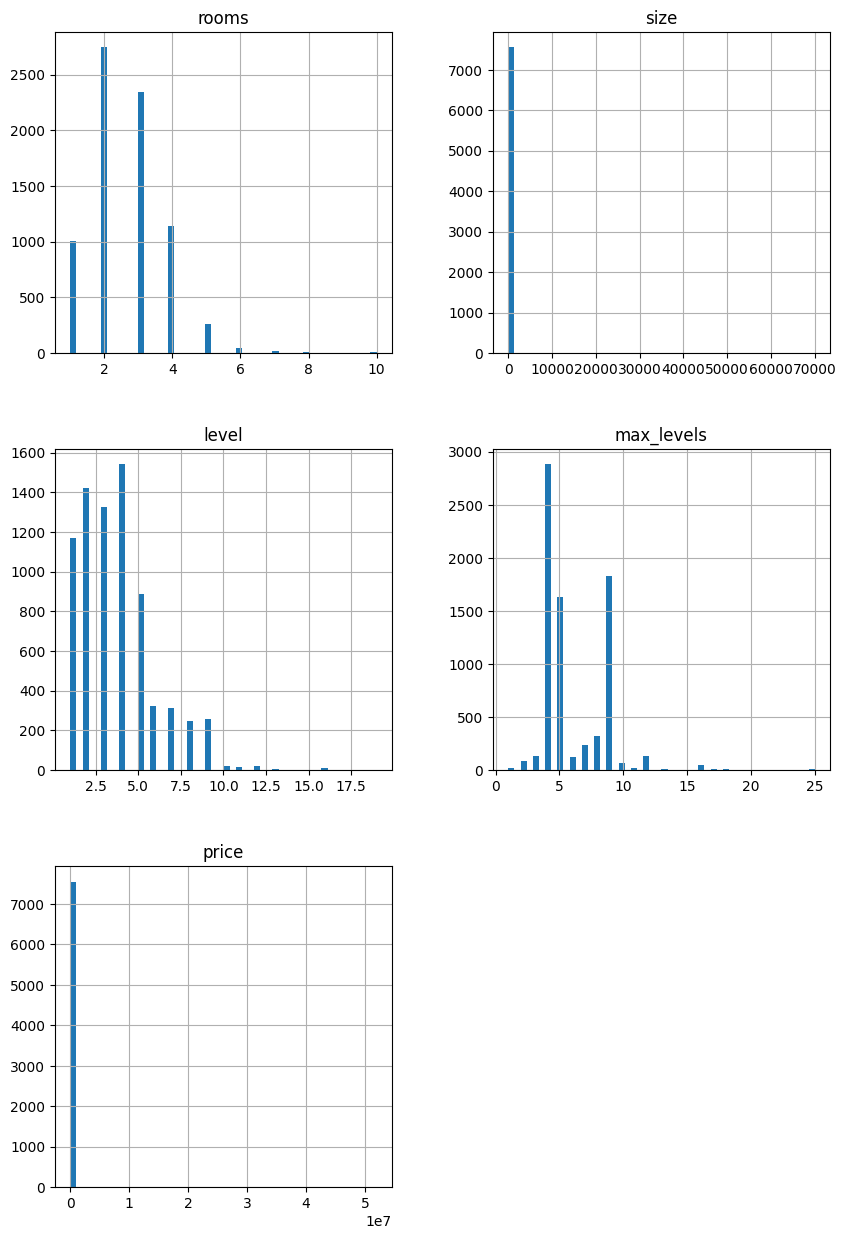

In [437]:
df.hist(bins = 50, figsize = (10,15))
plt.show()

In [438]:
df.corr(numeric_only=True)

,rooms,size,level,max_levels,price
rooms,1.000000,0.027877,0.133536,0.177717,0.055704
size,0.027877,1.000000,-0.011031,-0.011091,0.001106
level,0.133536,-0.011031,1.000000,0.591807,-0.003430
max_levels,0.177717,-0.011091,0.591807,1.000000,0.011068
price,0.055704,0.001106,-0.003430,0.011068,1.000000


#Data Preparation

In [439]:
df[['location', 'district']].head(10) # locationdagi tuman va districtdagi tuman nomi oxshashmi

,location,district
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский
5,"город Ташкент, Чиланзарский район, Чиланзар 6-...",Чиланзарский
6,"город Ташкент, Чиланзарский район, Чиланзар-16",Чиланзарский
7,"город Ташкент, Яккасарайский район, Саламатина",Яккасарайский
8,"город Ташкент, Учтепинский район, Чиланзар-21",Учтепинский
9,"город Ташкент, Чиланзарский район, Чиланзар-8",Чиланзарский


Working with outliers

In [440]:
df[['size', 'rooms']].sort_values('size',ascending = False).head(20) # 500 dan yuqori myadon olchamli qatorlarni tashlab yuboraman
df.drop(df[df['size'] >= 500].index, inplace = True)

In [441]:
idx  = df[(df.price > 300000) & (df.rooms < 7) & (df['size'] < 200)].index
df.drop(idx, inplace= True)

In [442]:
df['price'].sort_values(ascending = False).head(20)
idx2 = df[df.price > 400000].index
df.drop(idx2, inplace = True)

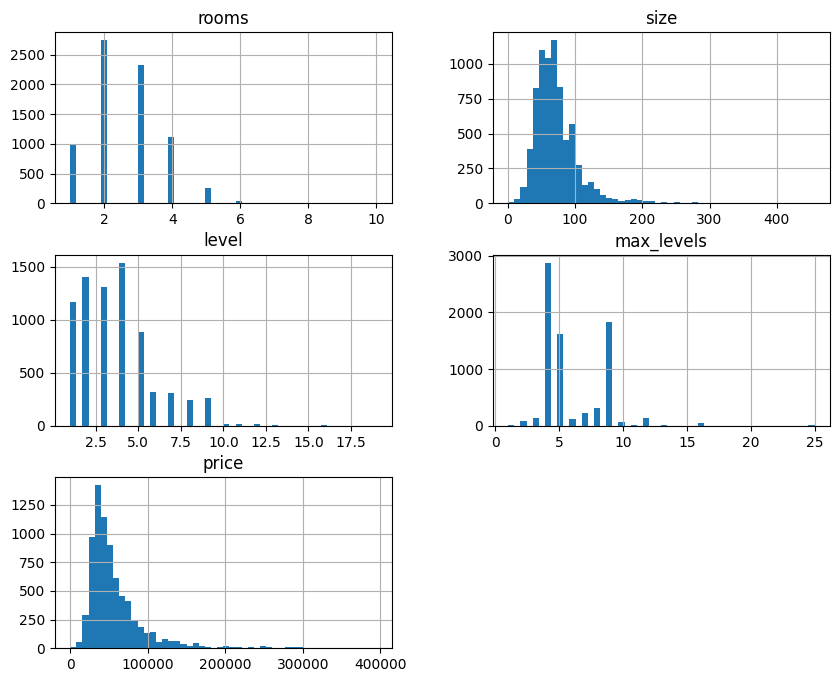

In [443]:
df.hist(bins = 50, figsize = (10, 8))
plt.show()

In [444]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
Index: 7519 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7519 non-null   object 
 1   district    7519 non-null   object 
 2   rooms       7519 non-null   int64  
 3   size        7519 non-null   float64
 4   level       7519 non-null   int64  
 5   max_levels  7519 non-null   int64  
 6   price       7519 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 469.9+ KB


In [445]:
df.location.value_counts()[df.location.value_counts()>20]

,count
location,
"город Ташкент, Чиланзарский район, Чиланзар",112
"город Ташкент, Яккасарайский район, Кушбеги",109
"город Ташкент, Мирзо-Улугбекский район, Буюк Ипак Йули",87
"город Ташкент, Яккасарайский район, Бабура",82
"город Ташкент, Учтепинский район, Чиланзар 24-й квартал",79
...,...
"город Ташкент, Учтепинский район, Чиланзар квартал Г9А",22
"город Ташкент, Юнусабадский район, Юнусабад 14-й квартал",22
"город Ташкент, Мирзо-Улугбекский район, Карасу 3-й квартал",22


In [446]:
df.describe()

,rooms,size,level,max_levels,price
count,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000
mean,2.616837,72.854623,3.701822,6.038170,57883.867779
std,1.068118,35.851121,2.239560,2.616583,39903.007806
min,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,50.000000,2.000000,4.000000,35000.000000
50%,3.000000,65.000000,3.000000,5.000000,46500.000000
75%,3.000000,85.000000,5.000000,9.000000,68000.000000
max,10.000000,456.000000,19.000000,25.000000,395000.000000


In [447]:
df.price.mean()

np.float64(57883.86777917766)

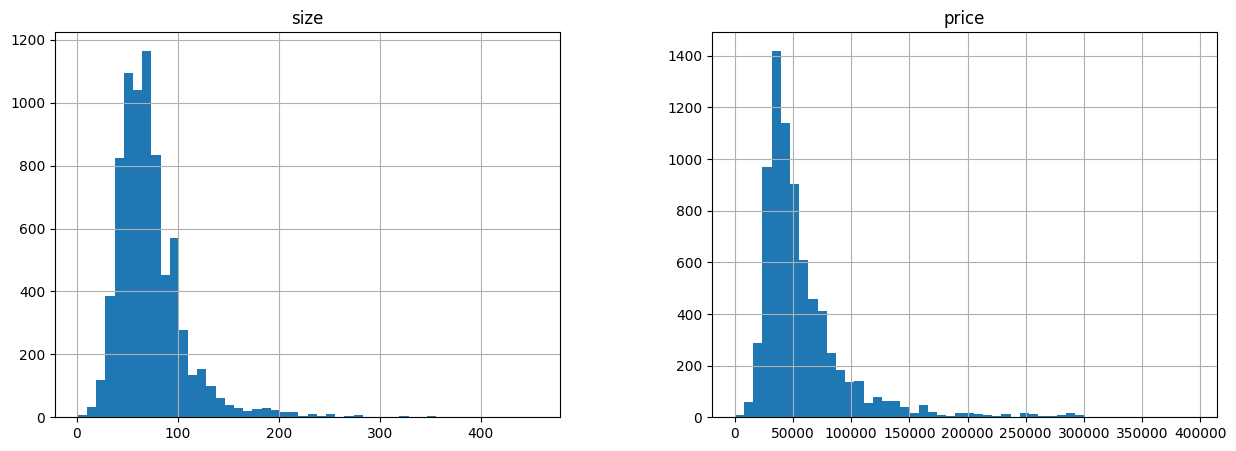

In [448]:
df[['size', 'price']].hist(bins = 50, figsize = (15,5))
plt.show()

In [449]:
df.corr(numeric_only=True)

,rooms,size,level,max_levels,price
rooms,1.000000,0.779255,0.135618,0.179472,0.572507
size,0.779255,1.000000,0.160530,0.275872,0.781697
level,0.135618,0.160530,1.000000,0.592176,0.071277
max_levels,0.179472,0.275872,0.592176,1.000000,0.241985
price,0.572507,0.781697,0.071277,0.241985,1.000000


#Data Preprocessing


In [450]:
df['size_per_room'] = df['size'] / df['rooms']

In [451]:
df.corrwith(df['price'], numeric_only=True).sort_values(ascending=False)

,0
price,1.000000
size,0.781697
rooms,0.572507
size_per_room,0.322900
max_levels,0.241985
level,0.071277


In [452]:
df.drop('location', axis = 1, inplace = True)

# Train and Test set split

In [453]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

In [454]:
housing = train_set.drop('price', axis = 1)
housing_num = housing.drop(['district'], axis = 1)
y = train_set['price']

# Working with string columns and Normalization

In [455]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(housing_num.columns)
cat_attribs = ['district']

full_pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared[:5]

array([[-1.51381303, -1.36066253, -1.20686316, -0.78536517, -0.59114316,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [-0.58296194,  0.29694879, -0.31697264, -0.78536517,  1.67833315,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [-0.58296194, -1.11202083,  1.90775365,  1.13229801, -1.53675829,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [-0.58296194, -0.697618  , -0.31697264, -0.40183253, -0.59114316,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        

# Build Machine Learning Model

Linear Regression


In [456]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()
LR_model.fit(housing_prepared, y)

LinearRegression()

In [457]:
test_data = housing.sample(20)
test_labels = y.loc[test_data.index]

test_prepared = full_pipeline.transform(test_data)

predicted_labels = LR_model.predict(test_prepared)

In [458]:
pd.DataFrame({'Prediction' : predicted_labels, 'Real':test_labels}).head()

,Prediction,Real
4577,48392.980440,48000.0
2334,43313.625822,68000.0
6009,49615.287221,56500.0
6024,25884.904696,29000.0
634,70487.383562,46000.0


In [459]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(test_labels, predicted_labels)
rmse

37291.86782065001

In [460]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test_labels, predicted_labels)
mae

16893.648026338917

Random Forest

In [461]:
from sklearn.ensemble import RandomForestRegressor

RF_model = RandomForestRegressor()

RF_model.fit(housing_prepared, y)

RandomForestRegressor()

In [462]:
predicted_labels_RF = RF_model.predict(test_prepared)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(test_labels, predicted_labels_RF)
rmse

10909.016209039253

In [463]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test_labels, predicted_labels_RF)
mae

5912.67560086898

In [464]:
from sklearn.tree import DecisionTreeRegressor
DT_model = DecisionTreeRegressor()
DT_model.fit(housing_prepared, y)

DecisionTreeRegressor()

In [465]:
predicted_labels_DT = DT_model.predict(test_prepared)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(test_labels, predicted_labels_DT)
rmse

3830.70053795486

In [466]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test_labels, predicted_labels_DT)
mae

2491.5727777777784

XGB Regressor

In [467]:
from xgboost import XGBRegressor

XGB_model = XGBRegressor(
     n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

XGB_model.fit(housing_prepared, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

# Test Set

In [468]:
test_set

,district,rooms,size,level,max_levels,price,size_per_room
2347,Мирзо-Улугбекский,1,33.0,4,4,23000.0,33.000000
7077,Шайхантахурский,4,85.0,3,4,53000.0,21.250000
3685,Яшнободский,3,78.0,5,5,36000.0,26.000000
4183,Чиланзарский,5,169.0,5,9,93000.0,33.800000
678,Учтепинский,4,109.0,5,9,55000.0,27.250000
...,...,...,...,...,...,...,...
4126,Мирабадский,2,65.0,2,9,60000.0,32.500000
7237,Мирабадский,3,70.0,2,4,60000.0,23.333333
1884,Мирзо-Улугбекский,3,90.0,2,9,51000.0,30.000000
1543,Яшнободский,2,58.5,3,6,23513.0,29.250000


In [469]:
X_test = test_set.drop('price', axis = 1)
y_test = test_set['price']

X_test_prepared = full_pipeline.transform(X_test)

In [470]:
y_predicted = RF_model.predict(X_test_prepared)

from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_predicted)
rmse

17185.049953256177

In [471]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_predicted)
mae

9405.610619776267

In [472]:
df_com = pd.DataFrame({'Predict':y_predicted, 'Real':y_test})
df_com[np.abs(df_com['Predict'] - df_com['Real'])> 15000]

,Predict,Real
1257,62075.035714,42000.000000
3052,193487.490000,320000.000000
5485,64638.282104,48000.000000
4921,43943.750000,65000.000000
7315,60618.805828,45000.000000
...,...,...
3938,128701.252104,155000.000000
3677,120611.241750,71334.210421
7133,136309.325782,95000.000000
601,79996.914208,124999.000000


#Cross Val score


In [473]:
X = df.drop('price', axis = 1)
y_cros = df['price'].copy()
X_prepared = full_pipeline.transform(X)

from sklearn.model_selection import cross_val_score
rmse_scores = cross_val_score(RF_model, X_prepared, y_cros, scoring = 'neg_mean_squared_error', cv = 5)

rmse  = np.sqrt(-rmse_scores)

print(f"""RMSE: {rmse}
      Mean:{rmse.mean()}
      STD: {rmse.std()}""")

RMSE: [16457.24838426 24988.83977219 23298.07134533 19995.72923307
 17508.51609145]
      Mean:20449.68096525934
      STD: 3271.4929721979415


Saving model

In [476]:
import joblib
filename = 'RF_model'
joblib.dump(RF_model, filename)

['RF_model']

Loading model

In [477]:
model = joblib.load(filename)